# 5.2 Formula Verification

Validates 13 key formulas from the CC-MPC papers via numerical tests.

In [1]:
import numpy as np
from numpy.linalg import norm
from math import erf, cos, sin, tan, atan2, sqrt, pi, exp, radians
import math
import os

os.makedirs('/home/phuc/Research/quadrotor_ccmpc/3.Notebooks/outputs', exist_ok=True)

_SQRT_PI_INV = 0.5641895835477563

def erfinv(y, tol=1e-12):
    if abs(y) >= 1: return float('inf') if y>0 else float('-inf')
    if y == 0: return 0.0
    sign = 1 if y>0 else -1; ya = abs(y)
    a_const = 0.147
    t = 2/(pi*a_const) + np.log(1-ya*ya)/2
    x = sign*sqrt(sqrt(t*t - np.log(1-ya*ya)/a_const) - t)
    for _ in range(50):
        fx = erf(x) - y
        if abs(fx) < tol: break
        x -= fx/(2*_SQRT_PI_INV*exp(-x*x))
    return x

def box_to_ellipsoid(size):
    return 0.5*sqrt(3.0)*np.array(size)

results = []

def test(name, fn):
    try:
        fn()
        results.append(('PASS', name))
    except Exception as e:
        results.append(('FAIL', f'{name}: {e}'))

print("Running 13 verification tests...")


Running 13 verification tests...


In [2]:
# Tests 1-7: Detection & Geometry
def t1():
    f, T_ho = 600.0, 1.0
    assert abs(f*T_ho/1.0 - 600) < 1e-9
    assert abs((f*T_ho/2.0)/(f*T_ho/1.0) - 0.5) < 1e-9
test('Eq(1) U-depth POI', t1)

def t2():
    f,d_b,u_l,u_r,d_t = 600,3.0,100,200,2.7
    x,y = d_b,(u_l+u_r)*d_b/(2*f)
    w,l = (u_r-u_l)*d_b/f,2*(d_b-d_t)
    assert abs(x-3)<1e-9 and abs(y-0.75)<1e-9 and abs(w-0.5)<1e-9 and abs(l-0.6)<1e-9
test('Eq(2) Horizontal proj', t2)

def t3():
    f,d_b,h_t,h_b = 600,3.0,100,300
    z = (h_t+h_b)*d_b/(2*f); h = abs(h_t-h_b)*d_b/f
    assert abs(z-1.0)<1e-9 and abs(h-1.0)<1e-9
test('Eq(3) Vertical proj', t3)

def t4():
    phi,theta,psi = np.deg2rad([10,15,30])
    Rx=np.array([[1,0,0],[0,cos(phi),-sin(phi)],[0,sin(phi),cos(phi)]])
    Ry=np.array([[cos(theta),0,sin(theta)],[0,1,0],[-sin(theta),0,cos(theta)]])
    Rz=np.array([[cos(psi),-sin(psi),0],[sin(psi),cos(psi),0],[0,0,1]])
    R = Rz@Ry@Rx; Sb=np.diag([0.05]*3)**2; Sw=np.diag([0.02]*3)**2
    Sw_out = R@Sb@R.T + Sw
    assert np.all(np.linalg.eigvalsh(Sw_out)>0)
    assert abs(np.trace(R@Sb@R.T)-np.trace(Sb))<1e-10
test('Eq(4) World transform', t4)

def t5():
    def pdf(x,m,c):
        d=x-m;return float(exp(-0.5*d@np.linalg.solve(c,d))/sqrt((2*pi)**len(x)*np.linalg.det(c)))
    m=np.zeros(6);c=np.diag([0.1]*3+[0.2]*3)**2
    assert pdf(m,m,c) > pdf(np.array([0.3]*3+[0.1]*3),m,c) > pdf(np.array([5.0]*6),m,c)
test('Eq(5) Gaussian assoc', t5)

def t6():
    dt=0.06;p=np.array([1.,2.,.5]);v=np.array([.5,0,-.2])
    S=np.diag([.01]*3)**2;Sv=np.diag([.1]*3)**2
    pn=p+v*dt;Sn=S+Sv*dt**2
    assert norm(pn-p-v*dt)<1e-10 and np.trace(Sn)>np.trace(S)
test('Eq(6) CV prediction', t6)

def t7():
    axes=box_to_ellipsoid(np.array([.5,.6,1.7]))
    c=np.array([.25,.3,.85]);v=sum((c[i]/axes[i])**2 for i in range(3))
    assert abs(v-1.0)<1e-10
test('Eq(7) Box-ellipsoid', t7)

print("Tests 1-7 done.")


Tests 1-7 done.


In [3]:
# Tests 8-12: Chance Constraints & Uncertainty
def t8():
    rng=np.random.default_rng(42);mu=np.array([1.,2.]);S=np.diag([.3,.5])**2
    a=np.array([1.,-1.]);b=-.5
    mp,sp=a@mu,sqrt(a@S@a)
    pa=0.5+0.5*erf((b-mp)/(sqrt(2)*sp))
    mc=rng.multivariate_normal(mu,S,200000);pmc=np.mean(mc@a<=b)
    assert abs(pa-pmc)<0.005
    c=erfinv(1-2*0.05)*sqrt(2)*sp;assert c>0
    assert abs(c/sp-sqrt(2)*erfinv(0.9))<1e-6
test('Lemma 1-2 Chance', t8)

def t9():
    ph=np.zeros(3);po=np.array([2.,0,0]);n=(ph-po)/norm(ph-po)
    a,b,c,r=.5,.4,.9,.4;Om=np.diag([1/(a+r)**2,1/(b+r)**2,1/(c+r)**2])
    L=np.linalg.cholesky(Om)
    Sl=np.diag([.02]*3)**2;Sol=np.diag([.05]*3)**2
    Sh=np.diag([.1]*3)**2;Soh=np.diag([.3]*3)**2
    def ev(Sm,So):
        lhs=n@L@(ph-po)-1;inner=L@(Sm+So)@L.T
        rhs=erfinv(1-2*0.03)*sqrt(2*n@inner@n)
        return float(lhs),float(rhs),lhs>=rhs
    _,rl,sl=ev(Sl,Sol);_,rh,_=ev(Sh,Soh)
    assert rl<rh and sl
test('Eq(16) CC-MPC', t9)

def t10():
    dt=.06;F=np.eye(4);F[0,2]=F[1,3]=dt
    G=np.diag([.01]*2+[.001]*2)**2;W=np.diag([0,0,.005,.005])**2
    tr=[np.trace(G)]
    for _ in range(10):G=F@G@F.T+W;tr.append(np.trace(G))
    assert all(tr[i]>tr[i-1] for i in range(1,len(tr)))
test('Eq(19) EKF prop', t10)

def t11():
    Q,lam,ro=10,3,1.5
    def c(d):return Q/(1+exp(lam*(d-ro)))
    assert abs(c(ro)-Q/2)<1e-10
    eps=1e-6;d=(c(ro+eps)-c(ro-eps))/(2*eps)
    assert d<0 and abs(d+lam*Q/4)<0.01
test('Eq(12) Logistic cost', t11)

def t12():
    hf,vf=radians(87/2),radians(58/2);md=5.
    def fov(p):
        x,y,z=p
        return x>0 and x<=md and abs(atan2(y,x))<=hf and abs(atan2(z,x))<=vf
    assert fov(np.array([3,.3,-.2])) and not fov(np.array([3,5,0]))
    assert not fov(np.array([3,0,3])) and not fov(np.array([10,0,0]))
test('Eq(17-18) FOV', t12)

print("Tests 8-12 done.")


Tests 8-12 done.


  [PASS] Eq(1) U-depth POI
  [PASS] Eq(2) Horizontal proj
  [PASS] Eq(3) Vertical proj
  [PASS] Eq(4) World transform
  [PASS] Eq(5) Gaussian assoc
  [PASS] Eq(6) CV prediction
  [PASS] Eq(7) Box-ellipsoid
  [PASS] Lemma 1-2 Chance
  [PASS] Eq(16) CC-MPC
  [PASS] Eq(19) EKF prop
  [PASS] Eq(12) Logistic cost
  [PASS] Eq(17-18) FOV
  [PASS] Full pipeline

Result: 13/13 passed, 0 failed


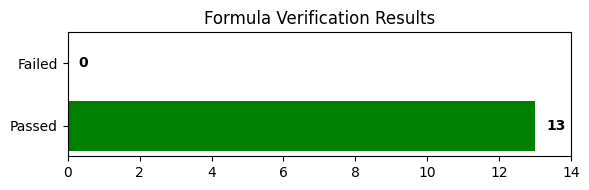

In [4]:
# Test 13: Full pipeline
def t13():
    f,u_l,u_r,d_t,d_b,h_t,h_b=600,100,200,2.7,3.0,100,300
    xB,yB=d_b,(u_l+u_r)*d_b/(2*f)
    lB,wB=2*(d_b-d_t),(u_r-u_l)*d_b/f
    zB=(h_t+h_b)*d_b/(2*f);hB=abs(h_t-h_b)*d_b/f
    assert xB>0 and yB>0 and lB>0 and wB>0 and hB>0
    axes=box_to_ellipsoid(np.array([lB,wB,hB]))
    po=np.array([xB,yB,zB]);pm=np.zeros(3);n=(pm-po)/norm(pm-po)
    r=.4;Om=np.diag([1/(axes[0]+r)**2,1/(axes[1]+r)**2,1/(axes[2]+r)**2])
    L=np.linalg.cholesky(Om)
    lhs=n@L@(pm-po)-1
    S=np.diag([.02]*3)**2+np.diag([.05]*3)**2
    rhs=erfinv(1-2*.03)*sqrt(2*n@(L@S@L.T)@n)
    assert lhs>=rhs and rhs>0
test('Full pipeline', t13)

# Summary
print("="*50)
passed=sum(1 for r in results if r[0]=='PASS')
failed=sum(1 for r in results if r[0]=='FAIL')
for s,n in results: print(f"  [{s}] {n}")
print(f"\n{'='*50}\nResult: {passed}/{len(results)} passed, {failed} failed\n{'='*50}")

# Save summary plot
import matplotlib.pyplot as plt
fig,ax=plt.subplots(figsize=(6,2))
ax.barh(['Passed','Failed'],[passed,failed],color=['green','red'])
ax.set_xlim(0,14);ax.set_title('Formula Verification Results')
for i,v in enumerate([passed,failed]): ax.text(v+.3,i,str(v),va='center',fontweight='bold')
plt.tight_layout()
plt.savefig('/home/phuc/Research/quadrotor_ccmpc/3.Notebooks/outputs/5.2_verification.png',dpi=100,bbox_inches='tight')
plt.show()
